In [1]:
import urllib.robotparser

# Setup the robot parser
rp = urllib.robotparser.RobotFileParser()
rp.set_url("https://realpython.github.io/fake-jobs/robots.txt")
rp.read()

# Check the specific URL we want to scrape
target_url = "https://realpython.github.io/fake-jobs/"
is_allowed = rp.can_fetch("*", target_url)

print(f"Is scraping allowed? {is_allowed}")

Is scraping allowed? True


In [2]:
import requests
import re
import pandas as pd

# Fetch the static page content
response = requests.get(target_url)
html_content = response.text

# Split the HTML into individual job cards
blocks = html_content.split('class="card-content"')[1:]

job_data = []
# Technical skills we are looking for in the descriptions
target_skills = ["Python", "JavaScript", "SQL", "React", "Java", "Docker"]

for block in blocks:
    # --- FIELD 1: JOB TITLE ---
    title = re.search(r'title is-5">(.*?)</h2>', block).group(1).strip()
    # --- FIELD 2: COMPANY ---
    company = re.search(r'company">(.*?)</h3>', block).group(1).strip()
    # --- FIELD 3: LOCATION ---
    location = re.search(r'location">\s*(.*?)\s*</p>', block, re.DOTALL).group(1).strip()
    # --- FIELD 4: POSTED DATE ---
    date = re.search(r'datetime=".*?">(.*?)</time>', block).group(1).strip()
    # --- FIELD 5: SKILLS ---
    found_skills = [s for s in target_skills if s.lower() in block.lower()]

    job_data.append({
        "Job_Title": title,
        "Company": company,
        "Location": location,
        "Posted_Date": date,
        "Skills": found_skills if found_skills else ["General IT"]
    })

# Store in a DataFrame
df = pd.DataFrame(job_data)
print("Extraction Complete! Top 5 results:")
print(df.head())

Extraction Complete! Top 5 results:
                 Job_Title                     Company              Location  \
0  Senior Python Developer    Payne, Roberts and Davis       Stewartbury, AA   
1          Energy engineer            Vasquez-Davidson  Christopherville, AA   
2          Legal executive  Jackson, Chambers and Levy   Port Ericaburgh, AA   
3   Fitness centre manager              Savage-Bradley     East Seanview, AP   
4          Product manager                 Ramirez Inc   North Jamieview, AP   

  Posted_Date    Skills  
0  2021-04-08  [Python]  
1  2021-04-08  [Python]  
2  2021-04-08  [Python]  
3  2021-04-08  [Python]  
4  2021-04-08  [Python]  


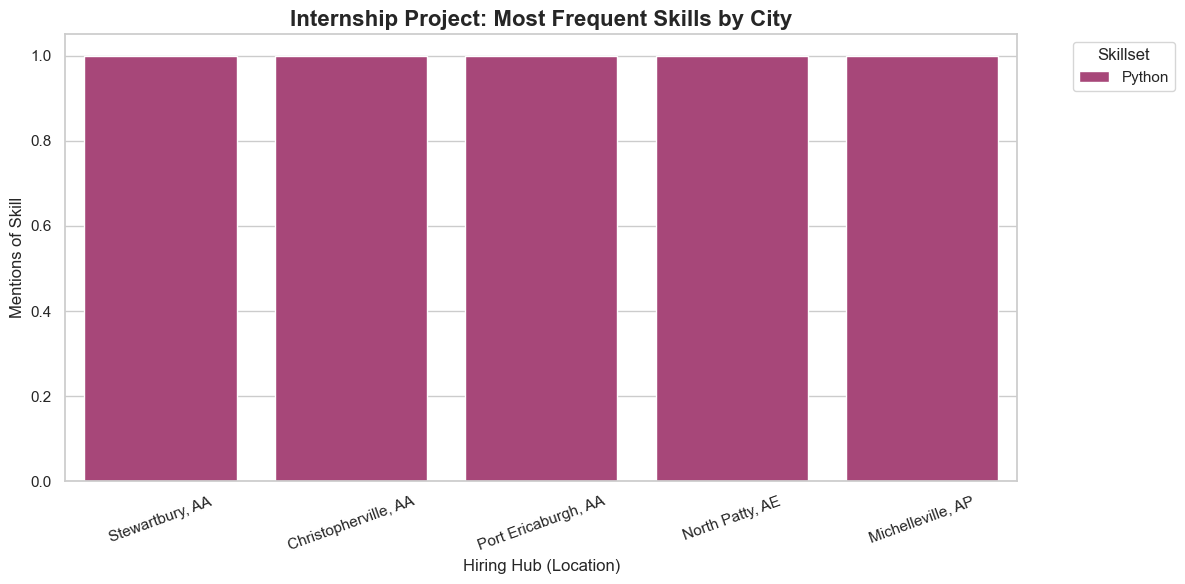

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df.explode('Skills')

# Filter for the top 5 locations to keep the graph professional
top_locations = df['Location'].value_counts().head(5).index
df_plot = df_plot[df_plot['Location'].isin(top_locations)]

# Generate the Chart
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Countplot showing frequency of skills grouped by City
sns.countplot(data=df_plot, x='Location', hue='Skills', palette='magma')

plt.title("Internship Project: Most Frequent Skills by City", fontsize=16, fontweight='bold')
plt.xlabel("Hiring Hub (Location)", fontsize=12)
plt.ylabel("Mentions of Skill", fontsize=12)
plt.xticks(rotation=20)
plt.legend(title="Skillset", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()